# Analisis Statistik Eksperimen Kriptografi
## RSA vs ECC — Smart Agriculture End-to-End Encryption

**Kolom data:**
- `enc_ms` : waktu enkripsi di gateway (ms)
- `dec_ms` : waktu dekripsi di server (ms)
- `net_ms` : waktu jaringan murni gateway↔server (ms)
- `e2e_ms` : end-to-end = enc + net + dec (ms)
- `payload_size_bytes` : ukuran ciphertext di server (bytes)

**Kombinasi:** RSA & ECC × 1KB, 10KB, 100KB × 30 runs = 180 baris

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import os
warnings.filterwarnings('ignore')

# ── Baca CSV ──
input_file = 'experiment_raw_1.csv'
num        = input_file.replace('experiment_raw_', '').replace('.csv', '')

# ── Output folder figur berdasarkan nama file input ──
# Setiap file input punya folder sendiri: figur/experiment_raw_3/
# Run berulang pada file yang sama → overwrite figur (folder sama)
fig_dir = os.path.join('figur', f'experiment_raw_{num}')
os.makedirs(fig_dir, exist_ok=True)
print(f'Folder figur : {fig_dir}')

# Styling
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLOR = {'RSA': '#E05C2A', 'ECC': '#1D9E75'}
SIZES = [1, 10, 100]
METRICS = ['enc_ms', 'dec_ms', 'net_ms', 'e2e_ms']
METRIC_LABEL = {
    'enc_ms': 'Enkripsi (ms)',
    'dec_ms': 'Dekripsi (ms)',
    'net_ms': 'Jaringan / net (ms)',
    'e2e_ms': 'End-to-End (ms)',
}

df = pd.read_csv(input_file).dropna(subset=['enc_ms'])
df['size_label'] = df['size_kb'].astype(str) + ' KB'
print(f'Input file   : {input_file}  ({len(df)} baris)')
df.head()

Folder figur : figur\experiment_raw_1
Input file   : experiment_raw_1.csv  (180 baris)


,run,mode,size_kb,enc_ms,dec_ms,net_ms,e2e_ms,payload_size_bytes,size_label
0,1,RSA,1,0.6608,33.0667,7.8863,41.6138,2883,1 KB
1,2,RSA,1,0.7385,35.3056,23.4724,59.5165,2883,1 KB
2,3,RSA,1,0.7563,38.5362,5.5555,44.8480,2883,1 KB
3,4,RSA,1,0.5557,30.1284,44.4953,75.1794,2883,1 KB
4,5,RSA,1,0.4581,29.0899,25.9995,55.5475,2883,1 KB


## 1. Statistik Deskriptif Lengkap

In [2]:
stats = df.groupby(['mode', 'size_kb'])[METRICS].agg(
    ['mean', 'std', 'min', 'max', 'median']
).round(4)

# Flatten kolom
stats.columns = ['_'.join(c) for c in stats.columns]
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(stats.to_string())

              enc_ms_mean  enc_ms_std  enc_ms_min  enc_ms_max  enc_ms_median  dec_ms_mean  dec_ms_std  dec_ms_min  dec_ms_max  dec_ms_median  net_ms_mean  net_ms_std  net_ms_min  net_ms_max  net_ms_median  e2e_ms_mean  e2e_ms_std  e2e_ms_min  e2e_ms_max  e2e_ms_median
mode size_kb                                                                                                                                                                                                                                                                
ECC  1             1.2444      0.4759      0.4792      2.1875         1.2145       1.1613      0.3205      0.6103      2.1872         1.1644      26.7302     13.2076      7.8276     58.8151        24.6452      29.1359     13.3518      9.5715     61.8684        26.2642
     10            1.3382      0.7756      0.6819      4.4502         1.1404       1.2851      0.3938      0.6776      2.3476         1.1586      19.6971     12.0751      7.4609     50.9344    

In [3]:
# Tabel ringkas mean ± stdev per metrik
print('=' * 70)
print(f'{"":30} {"enc_ms":>14} {"dec_ms":>14} {"net_ms":>14} {"e2e_ms":>14}')
print('=' * 70)
for mode in ['RSA', 'ECC']:
    for size in SIZES:
        sub = df[(df['mode'] == mode) & (df['size_kb'] == size)]
        label = f'{mode} {size:>3}KB'
        vals = [f"{sub[m].mean():.2f}±{sub[m].std():.2f}" for m in METRICS]
        print(f'  {label:<28} {vals[0]:>14} {vals[1]:>14} {vals[2]:>14} {vals[3]:>14}')
    print('-' * 70)
print('Format: mean ± stdev (ms)')

                                       enc_ms         dec_ms         net_ms         e2e_ms
  RSA   1KB                         0.58±0.15     34.43±5.70    18.32±11.36    53.32±11.89
  RSA  10KB                         0.95±0.59    99.10±53.51    16.80±10.65   116.85±55.49
  RSA 100KB                         1.22±0.41   104.36±16.05    32.45±16.96   138.03±27.94
----------------------------------------------------------------------
  ECC   1KB                         1.24±0.48      1.16±0.32    26.73±13.21    29.14±13.35
  ECC  10KB                         1.34±0.78      1.29±0.39    19.70±12.08    22.32±12.21
  ECC 100KB                         1.63±0.51      1.75±0.62    31.72±12.68    35.10±12.66
----------------------------------------------------------------------
Format: mean ± stdev (ms)


In [4]:
# ── Export statistik ringkas ke CSV ──
stats_out = df.groupby(['mode', 'size_kb']).agg(
    n_runs                   = ('enc_ms',             'count'),
    enc_mean_ms              = ('enc_ms',             'mean'),
    enc_stdev_ms             = ('enc_ms',             'std'),
    dec_mean_ms              = ('dec_ms',             'mean'),
    dec_stdev_ms             = ('dec_ms',             'std'),
    net_mean_ms              = ('net_ms',             'mean'),
    net_stdev_ms             = ('net_ms',             'std'),
    e2e_mean_ms              = ('e2e_ms',             'mean'),
    e2e_stdev_ms             = ('e2e_ms',             'std'),
    payload_size_mean_bytes  = ('payload_size_bytes', 'mean'),
    payload_size_stdev_bytes = ('payload_size_bytes', 'std'),
).round(4).reset_index()

stats_file = f'experiment_raw_{num}_stats.csv'
stats_out.to_csv(stats_file, index=False)
print(f'Tersimpan: {stats_file}')
stats_out

Tersimpan: experiment_raw_1_stats.csv


,mode,size_kb,n_runs,enc_mean_ms,enc_stdev_ms,dec_mean_ms,dec_stdev_ms,net_mean_ms,net_stdev_ms,e2e_mean_ms,e2e_stdev_ms,payload_size_mean_bytes,payload_size_stdev_bytes
0,ECC,1,30,1.2444,0.4759,1.1613,0.3205,26.7302,13.2076,29.1359,13.3518,2437.6000,0.6215
1,ECC,10,30,1.3382,0.7756,1.2851,0.3938,19.6971,12.0751,22.3204,12.2076,20869.7000,0.4661
2,ECC,100,30,1.6324,0.5128,1.7492,0.6204,31.7202,12.6782,35.1018,12.6623,205189.4333,0.5683
3,RSA,1,30,0.5776,0.1547,34.4277,5.7044,18.3190,11.3574,53.3243,11.8867,2883.6667,0.4795
4,RSA,10,30,0.9490,0.5858,99.0984,53.5110,16.7993,10.6490,116.8468,55.4915,21315.6000,0.5632
5,RSA,100,30,1.2243,0.4053,104.3593,16.0461,32.4455,16.9631,138.0291,27.9412,205635.5667,0.6261


## 2. Perbandingan Mean per Metrik (Bar Chart)

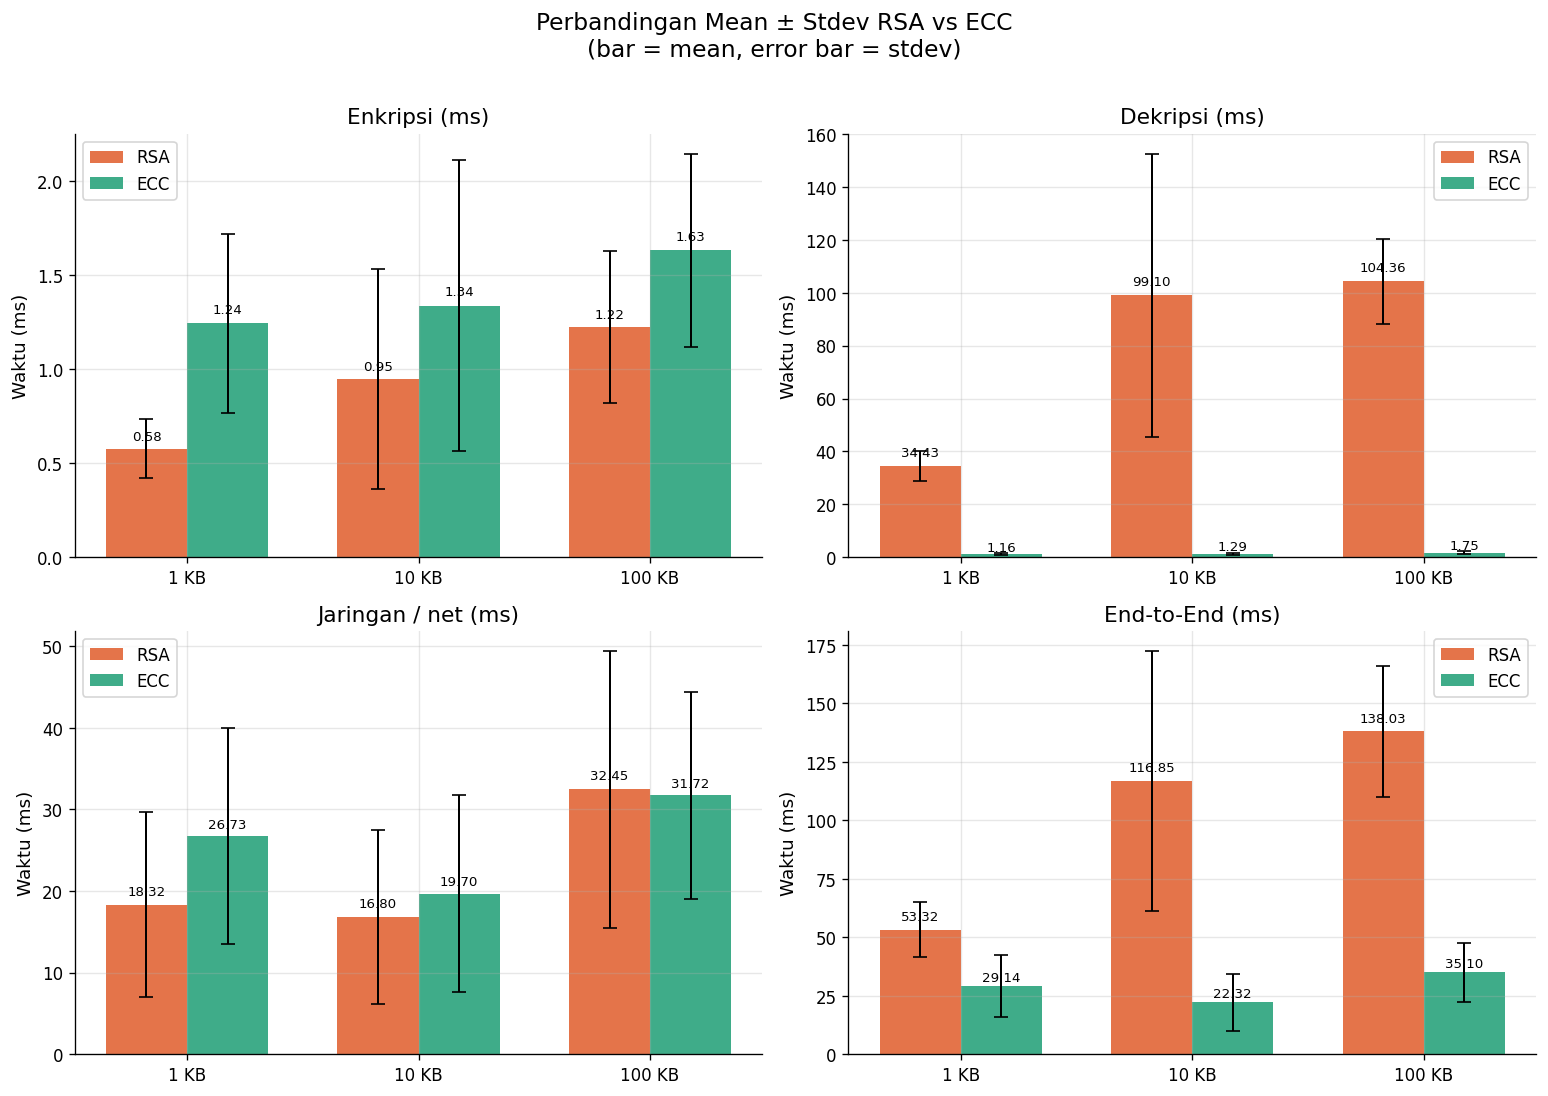

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
x = np.arange(len(SIZES))
width = 0.35

for ax, metric in zip(axes, METRICS):
    for i, mode in enumerate(['RSA', 'ECC']):
        means = [df[(df['mode']==mode)&(df['size_kb']==s)][metric].mean() for s in SIZES]
        stds  = [df[(df['mode']==mode)&(df['size_kb']==s)][metric].std()  for s in SIZES]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, means, width, label=mode,
                      color=COLOR[mode], alpha=0.85,
                      yerr=stds, capsize=4, error_kw={'linewidth': 1.2})
        for bar, mean in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.05,
                    f'{mean:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_title(METRIC_LABEL[metric])
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s} KB' for s in SIZES])
    ax.set_ylabel('Waktu (ms)')
    ax.legend()

fig.suptitle('Perbandingan Mean ± Stdev RSA vs ECC\n(bar = mean, error bar = stdev)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'bar_mean_stdev.png'), bbox_inches='tight')
plt.show()

## 3. Distribusi Data per Run (Box Plot)

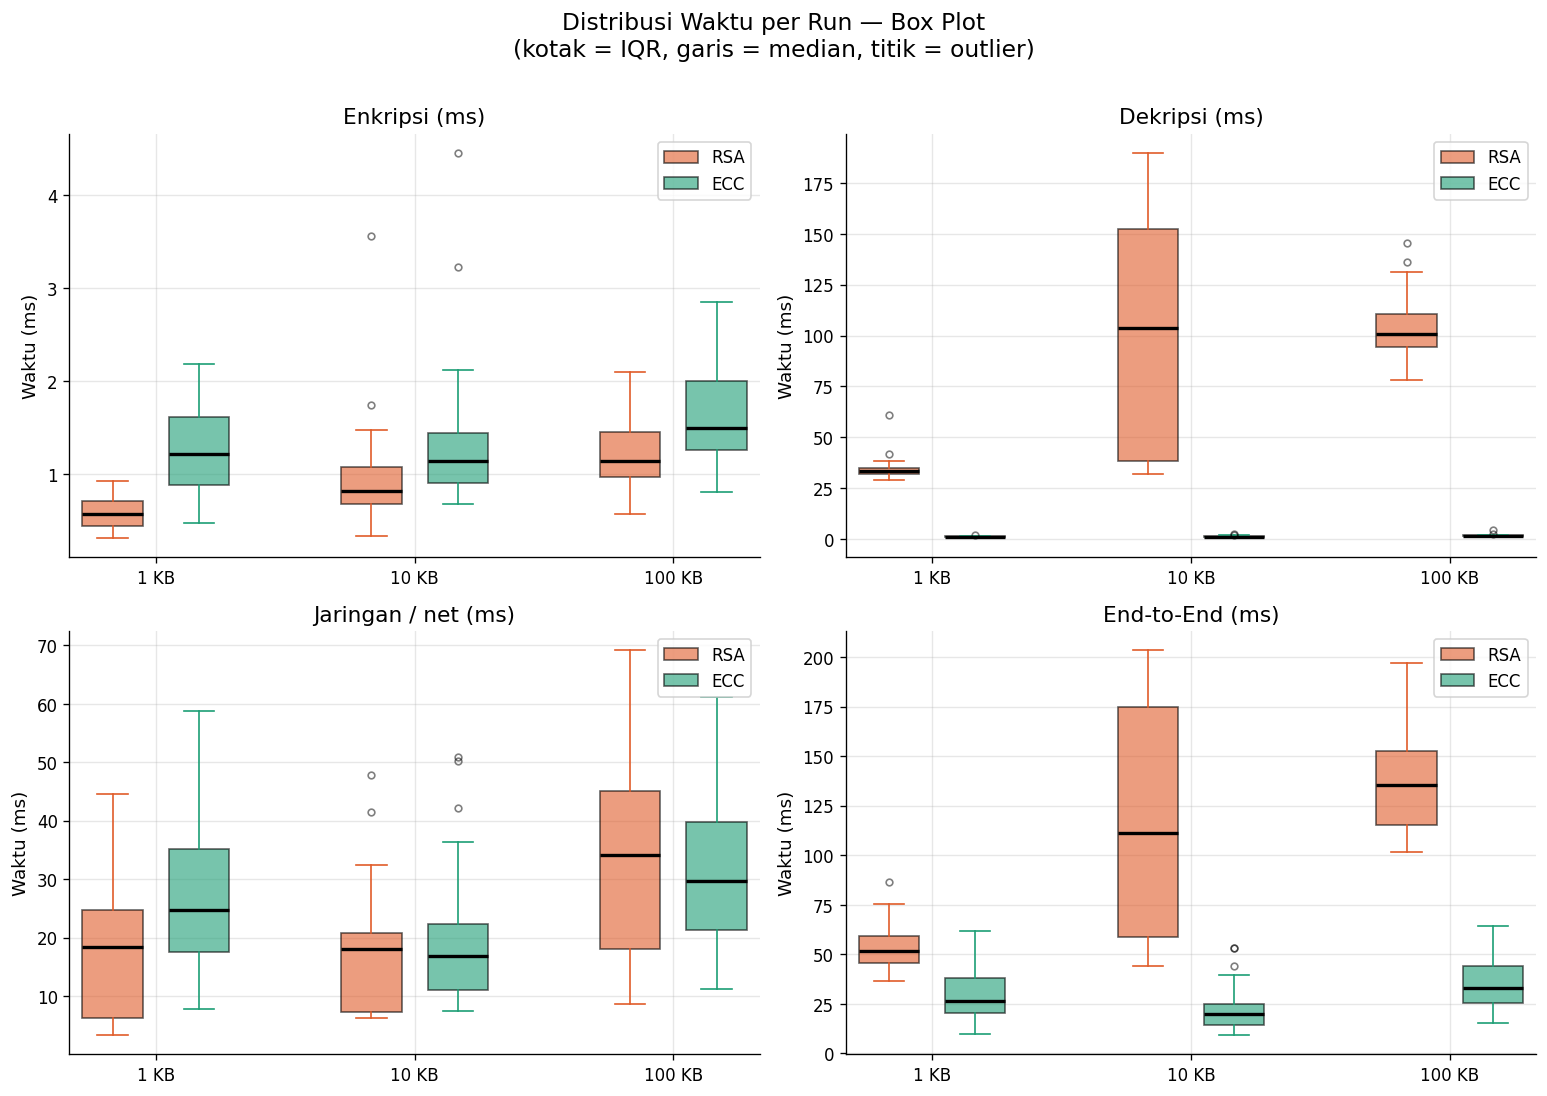

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, metric in zip(axes, METRICS):
    data_rsa = [df[(df['mode']=='RSA')&(df['size_kb']==s)][metric].values for s in SIZES]
    data_ecc = [df[(df['mode']=='ECC')&(df['size_kb']==s)][metric].values for s in SIZES]

    positions_rsa = [1, 4, 7]
    positions_ecc = [2, 5, 8]

    bp_rsa = ax.boxplot(data_rsa, positions=positions_rsa, widths=0.7,
                        patch_artist=True, notch=False,
                        boxprops=dict(facecolor=COLOR['RSA'], alpha=0.6),
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(color=COLOR['RSA']),
                        capprops=dict(color=COLOR['RSA']),
                        flierprops=dict(marker='o', color=COLOR['RSA'], markersize=4, alpha=0.5))

    bp_ecc = ax.boxplot(data_ecc, positions=positions_ecc, widths=0.7,
                        patch_artist=True, notch=False,
                        boxprops=dict(facecolor=COLOR['ECC'], alpha=0.6),
                        medianprops=dict(color='black', linewidth=2),
                        whiskerprops=dict(color=COLOR['ECC']),
                        capprops=dict(color=COLOR['ECC']),
                        flierprops=dict(marker='o', color=COLOR['ECC'], markersize=4, alpha=0.5))

    ax.set_title(METRIC_LABEL[metric])
    ax.set_xticks([1.5, 4.5, 7.5])
    ax.set_xticklabels([f'{s} KB' for s in SIZES])
    ax.set_ylabel('Waktu (ms)')
    ax.legend([bp_rsa['boxes'][0], bp_ecc['boxes'][0]], ['RSA', 'ECC'])

fig.suptitle('Distribusi Waktu per Run — Box Plot\n(kotak = IQR, garis = median, titik = outlier)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'boxplot_distribusi.png'), bbox_inches='tight')
plt.show()

## 4. Tren Waktu per Run (Line Plot — Stabilitas)

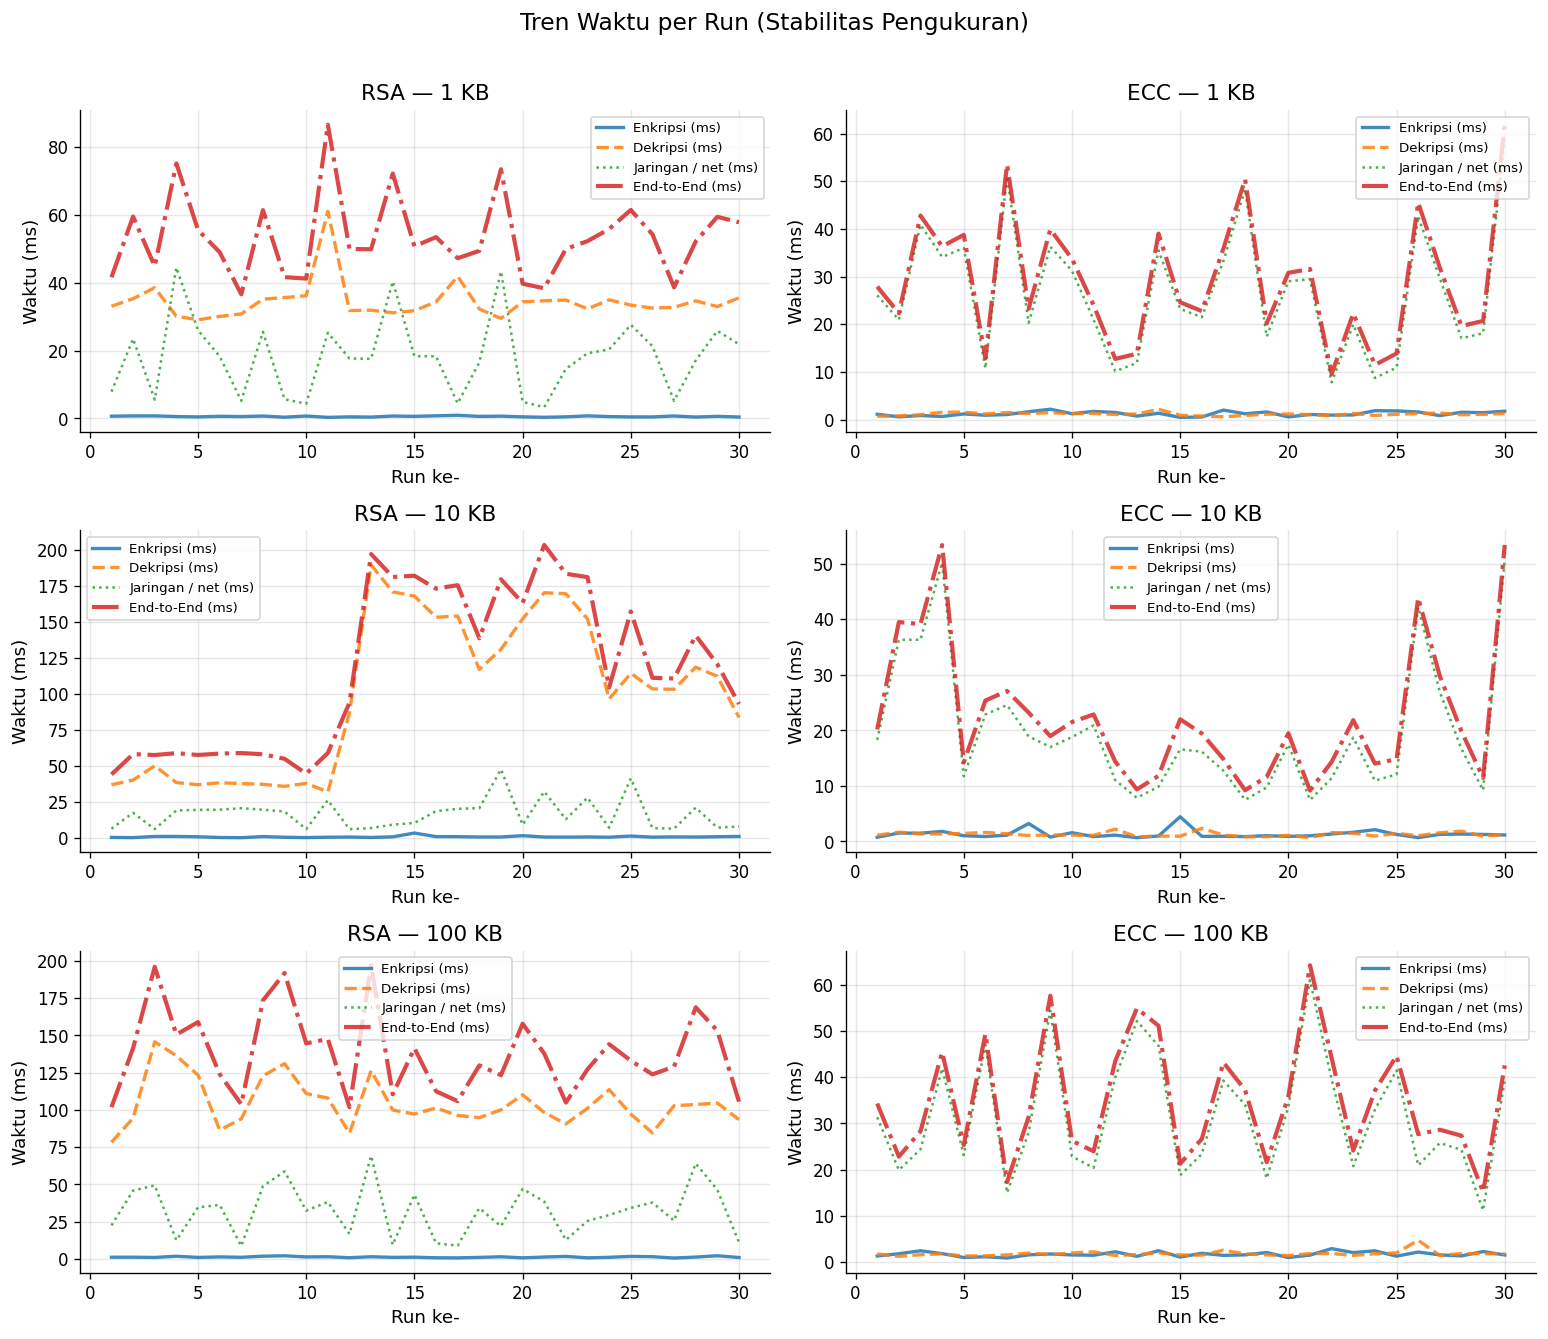

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharey=False)

for row, size in enumerate(SIZES):
    for col, mode in enumerate(['RSA', 'ECC']):
        ax = axes[row][col]
        sub = df[(df['mode']==mode) & (df['size_kb']==size)].reset_index(drop=True)

        for metric, ls, lw in zip(
            METRICS,
            ['-', '--', ':', '-.'],
            [2, 2, 1.5, 2.5]
        ):
            ax.plot(sub['run'], sub[metric], linestyle=ls, linewidth=lw,
                    label=METRIC_LABEL[metric], alpha=0.85)

        ax.set_title(f'{mode} — {size} KB')
        ax.set_xlabel('Run ke-')
        ax.set_ylabel('Waktu (ms)')
        ax.legend(fontsize=8)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

fig.suptitle('Tren Waktu per Run (Stabilitas Pengukuran)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'lineplot_trend.png'), bbox_inches='tight')
plt.show()

## 5. Komposisi Waktu E2E (Stacked Bar)

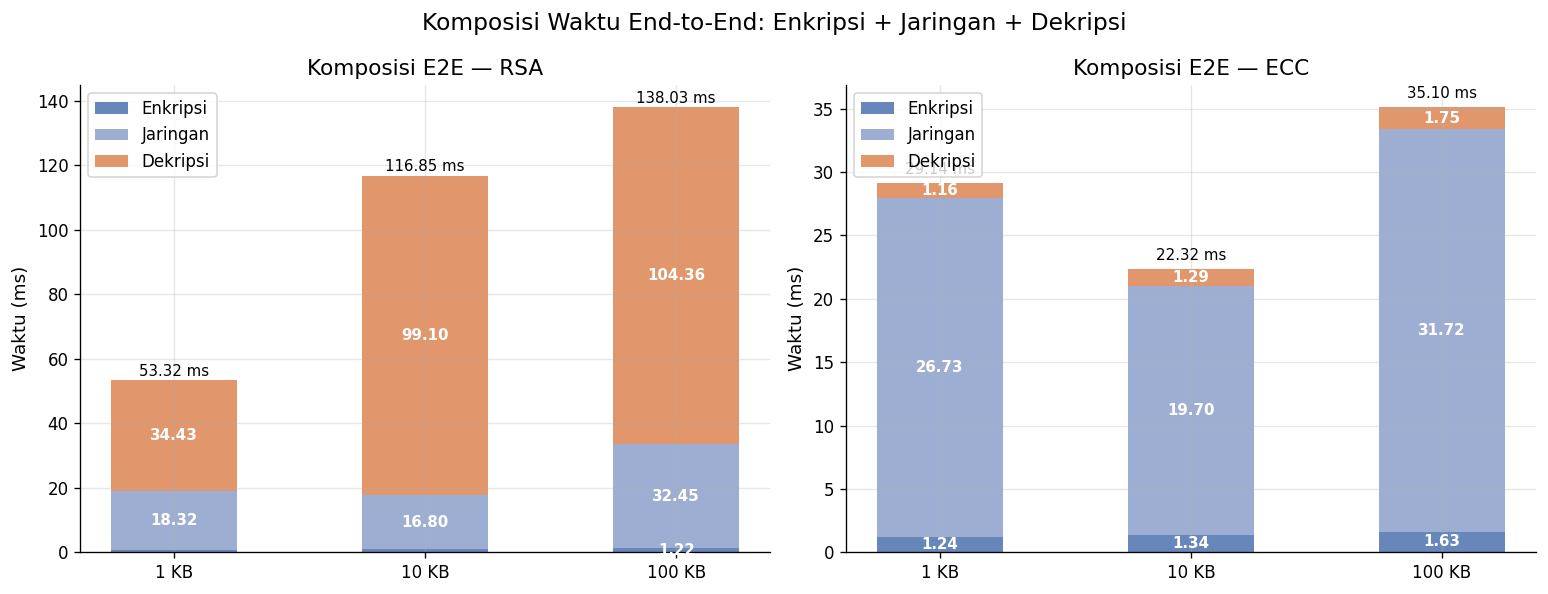

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

components = ['enc_ms', 'net_ms', 'dec_ms']
comp_labels = ['Enkripsi', 'Jaringan', 'Dekripsi']
comp_colors = ['#4C72B0', '#8DA0CB', '#DD8452']

x = np.arange(len(SIZES))
width = 0.5

for ax, mode in zip(axes, ['RSA', 'ECC']):
    bottoms = np.zeros(len(SIZES))
    for comp, label, color in zip(components, comp_labels, comp_colors):
        means = [df[(df['mode']==mode)&(df['size_kb']==s)][comp].mean() for s in SIZES]
        bars = ax.bar(x, means, width, bottom=bottoms, label=label, color=color, alpha=0.85)
        # Label nilai di dalam bar jika cukup besar
        for bar, val, bot in zip(bars, means, bottoms):
            if val > 1:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bot + val/2,
                        f'{val:.2f}', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottoms += np.array(means)

    # Label total e2e di atas bar
    for xi, bot in zip(x, bottoms):
        ax.text(xi, bot + 0.5, f'{bot:.2f} ms', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'Komposisi E2E — {mode}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s} KB' for s in SIZES])
    ax.set_ylabel('Waktu (ms)')
    ax.legend(loc='upper left')

fig.suptitle('Komposisi Waktu End-to-End: Enkripsi + Jaringan + Dekripsi',
             fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'stacked_komposisi.png'), bbox_inches='tight')
plt.show()

## 6. Ukuran Payload Ciphertext

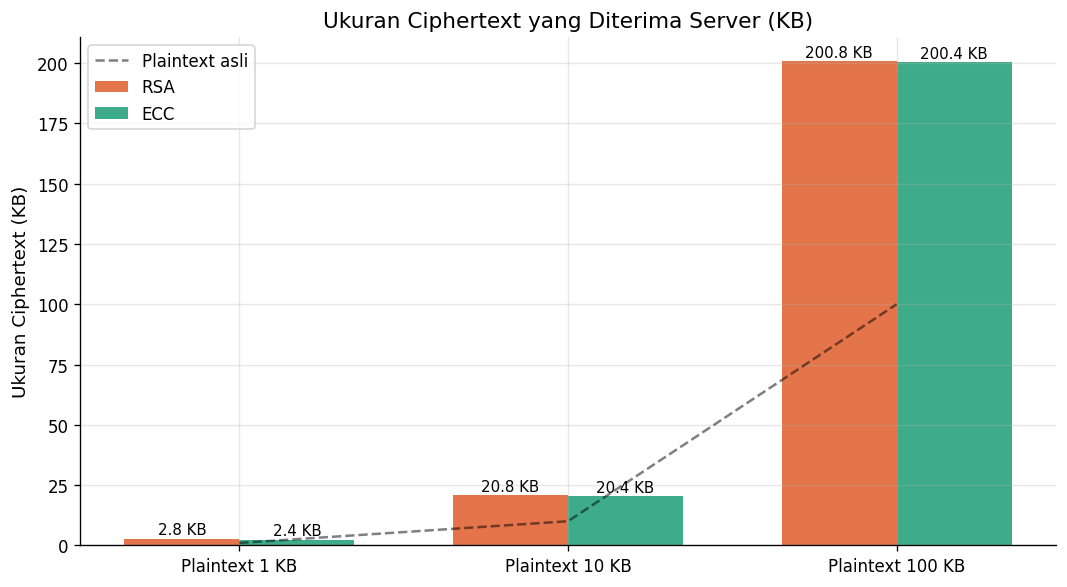


Rasio ekspansi ciphertext vs plaintext:
                          RSA        ECC
  Plaintext   1 KB         2.82x      2.38x
  Plaintext  10 KB         2.08x      2.04x
  Plaintext 100 KB         2.01x      2.00x


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(SIZES))
width = 0.35

for i, mode in enumerate(['RSA', 'ECC']):
    means = [df[(df['mode']==mode)&(df['size_kb']==s)]['payload_size_bytes'].mean()/1024
             for s in SIZES]
    bars = ax.bar(x + (i-0.5)*width, means, width,
                  label=mode, color=COLOR[mode], alpha=0.85)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f} KB', ha='center', va='bottom', fontsize=9)

ax.set_title('Ukuran Ciphertext yang Diterima Server (KB)')
ax.set_xticks(x)
ax.set_xticklabels([f'Plaintext {s} KB' for s in SIZES])
ax.set_ylabel('Ukuran Ciphertext (KB)')
ax.legend()

# Garis plaintext asli sebagai referensi
ax.plot(x, SIZES, 'k--', linewidth=1.5, label='Plaintext asli', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'payload_size.png'), bbox_inches='tight')
plt.show()

print('\nRasio ekspansi ciphertext vs plaintext:')
print(f'{"":18} {"RSA":>10} {"ECC":>10}')
for size in SIZES:
    for mode in ['RSA', 'ECC']:
        mean_bytes = df[(df['mode']==mode)&(df['size_kb']==size)]['payload_size_bytes'].mean()
        ratio = mean_bytes / (size * 1024)
        if mode == 'RSA':
            print(f'  Plaintext {size:>3} KB   {ratio:>10.2f}x', end='')
        else:
            print(f'{ratio:>10.2f}x')

## 7. Coefficient of Variation — Konsistensi Pengukuran

In [10]:
print('Coefficient of Variation (CV = stdev/mean × 100%) — makin kecil makin konsisten')
print('=' * 72)
print(f'{"":28} {"enc_ms":>10} {"dec_ms":>10} {"net_ms":>10} {"e2e_ms":>10}')
print('-' * 72)

for mode in ['RSA', 'ECC']:
    for size in SIZES:
        sub = df[(df['mode']==mode) & (df['size_kb']==size)]
        cvs = [f"{(sub[m].std()/sub[m].mean()*100):.1f}%" for m in METRICS]
        print(f'  {mode} {size:>3}KB                  {cvs[0]:>10} {cvs[1]:>10} {cvs[2]:>10} {cvs[3]:>10}')
    print('-' * 72)

Coefficient of Variation (CV = stdev/mean × 100%) — makin kecil makin konsisten
                                 enc_ms     dec_ms     net_ms     e2e_ms
------------------------------------------------------------------------
  RSA   1KB                       26.8%      16.6%      62.0%      22.3%
  RSA  10KB                       61.7%      54.0%      63.4%      47.5%
  RSA 100KB                       33.1%      15.4%      52.3%      20.2%
------------------------------------------------------------------------
  ECC   1KB                       38.2%      27.6%      49.4%      45.8%
  ECC  10KB                       58.0%      30.6%      61.3%      54.7%
  ECC 100KB                       31.4%      35.5%      40.0%      36.1%
------------------------------------------------------------------------


## 8. Perbandingan Langsung RSA vs ECC (Ratio)

In [11]:
print('Rasio RSA/ECC (nilai > 1 = RSA lebih lambat dari ECC)')
print('=' * 60)
print(f'{"":15} {"enc_ms":>12} {"dec_ms":>12} {"e2e_ms":>12}')
print('-' * 60)

for size in SIZES:
    rsa = df[(df['mode']=='RSA') & (df['size_kb']==size)]
    ecc = df[(df['mode']=='ECC') & (df['size_kb']==size)]
    ratios = []
    for m in ['enc_ms', 'dec_ms', 'e2e_ms']:
        r = rsa[m].mean() / ecc[m].mean()
        ratios.append(f'{r:.2f}x')
    print(f'  {size:>3} KB          {ratios[0]:>12} {ratios[1]:>12} {ratios[2]:>12}')

print()
print('Interpretasi:')
for size in SIZES:
    rsa_e2e = df[(df['mode']=='RSA')&(df['size_kb']==size)]['e2e_ms'].mean()
    ecc_e2e = df[(df['mode']=='ECC')&(df['size_kb']==size)]['e2e_ms'].mean()
    faster = ((rsa_e2e - ecc_e2e) / rsa_e2e * 100)
    print(f'  {size:>3} KB: ECC lebih cepat {faster:.1f}% dari RSA dalam E2E')

Rasio RSA/ECC (nilai > 1 = RSA lebih lambat dari ECC)
                      enc_ms       dec_ms       e2e_ms
------------------------------------------------------------
    1 KB                 0.46x       29.65x        1.83x
   10 KB                 0.71x       77.11x        5.23x
  100 KB                 0.75x       59.66x        3.93x

Interpretasi:
    1 KB: ECC lebih cepat 45.4% dari RSA dalam E2E
   10 KB: ECC lebih cepat 80.9% dari RSA dalam E2E
  100 KB: ECC lebih cepat 74.6% dari RSA dalam E2E
